# CO2 Emmissions by cars 


## **Project Definition and Goal**<br> 



### Identifyng the car technical characteristics <br> that play a role in pollution 

<span style="font-size: 18px">

- This project aims to identify which technical characteristics<br>
of newly registered vehicles most influence their CO₂ emissions.<br>
Our goal is to uncover patterns and predictors of emissions<br>
performance that can inform sustainable vehicle design, <br>
manufacturing strategies, and environmental policy<br>

<br>
    To develop a robust and well-tested approach, we begin<br>
with a focused exploratory analysis using a 2013 dataset<br>
of cars sold in France. Once the analytical pipeline<br>
is validated on this smaller, simpler dataset,<br>
we will apply the same methodology to the<br>
full-scale European Environment Agency (EEA) 2023<br> dataset.
This ensures both efficiency in development and <br>
relevance in our final insights.<br>

## **Datasets Overview**



We'll begin our study with two datasets:

### 1. **France 2013 dataset** (initial EDA phase)

- Contains technical and environmental specifications of passenger cars sold in France in 2013  
- Includes CO₂ emissions, fuel consumption, engine power, mass, and fuel type  
- Used to prototype visualizations, hypothesis tests, and feature selection  

### 2. **EEA 2023 dataset** (main analysis phase)

- Covers all new passenger cars registered in the European Union in 2023  
- Includes updated WLTP-based CO₂ measurements and richer technical data  
- Used to produce the final results and insights relevant to current EU mobility trends  

### Column Glossary: 2013 France Vehicles Dataset

<span style="font-size: 12px">


| **French Column**                                | **English Translation**                   | **Description** |
|--------------------------------------------------|-------------------------------------------|-----------------|
| Marque                                           | `Brand`                                     | Manufacturer of the vehicle (e.g., Renault, BMW). |
| Modèle dossier                                   | `Project_Model`                             | Internal project name used by the manufacturer — <br> less common externally. |
| Modèle UTAC                                      | `UTAC_Model`                                | Model name recognized by UTAC (French vehicle testing <br> authority). |
| Désignation commerciale                          | `Commercial_Name`                           | The marketed model name (e.g., “Clio 4”). |
| CNIT                                             | `CNIT (National Type ID Code)`              | French national Type Identification Code <br> used in registration documents;<br> 12–15 alphanumeric characters. |
| Type Variante Version (TVV)                      | `Type‑Variant‑Version (TVV)`               | Vehicle’s homologation code indicating <br> chassis type, variant, and version. |
| Carburant                                        | `Fuel_Type `                                | The type of fuel used (e.g., gasoline, diesel, electric). |
| Hybride                                          | `Hybrid`                                    | Indicates if the vehicle is hybrid (yes/no or binary indicator). |
| Puissance administrative                         | `Fiscal_Power(CV)`                         | A taxation metric used in France, not actual engine power. |
| Puissance maximale (kW)                          | `Max_Power(kW)`                             | Actual engine power output in kilowatts. |
| Boîte de vitesse                                 | `Gearbox`                                   | Transmission type (manual, automatic, CVT, etc.). |
| Consommation urbaine (l/100km)                   | `Urban_Consumption(L/100km)`                | Fuel consumption in city driving. |
| Consommation extra-urbaine (l/100km)             | `Extra‑urban_Consumption(L/100km)`          | Fuel consumption on highways. |
| Consommation mixte (l/100km)                     | `Combined_Consumption(L/100km)`             | Overall fuel consumption combining urban and highway. |
| CO2 (g/km)                                       | `CO2_Emissions(g/km)`                       | Carbon dioxide emissions per kilometer. |
| CO type I (g/km)                                 | `CO_Type_I(g/km)`                           | Carbon monoxide emissions (test cycle I). |
| HC (g/km)                                        | `Hydrocarbons(g/km)`                        | Hydrocarbon emissions per kilometer. |
| NOX (g/km)                                       | `Nitrogen Oxides(g/km)`                     | NOx emissions per kilometer. |
| HC+NOX (g/km)                                    | `HC + NOx(g/km)`                            | Combined hydrocarbon and nitrogen oxide emissions. |
| Particules (g/km)                                | `Particles(g/km)`                           | Particulate matter emissions (e.g., soot). |
| masse vide euro min (kg)                         | `Unladen_Mass_Euro_Min(kg)`                 | Minimum curb weight under Euro standards. |
| masse vide euro max (kg)                         | `Unladen_Mass_Euro_Max(kg)`                 | Maximum curb weight under Euro standards. |
| Champ V9                                         | `Field_V9`                                  | Unknown – no standard meaning found. |
| Date de mise à jour                              | `Update_Date`                               | Last update of the record. |
| Carrosserie                                      | `Body_Type`                                 | Vehicle body style (e.g., sedan, SUV, hatchback). |
| gamme                                            | `Segment/Range`                             | Vehicle category (e.g., compact, luxury). |

### Column Descriptions — 2023 EEA


<span style="font-size: 12px">

| Column Name     | Description                          |
|------------------|--------------------------------------|
| `id`             | Unique vehicle ID                   |
| `MS`             | Member State code                   |
| `MP`             | Manufacturer / Production code      |
| `Mh`             | Manufacturer name                   |
| `MAN`            | Make and model name                 |
| `MMS`            | Marketing model name                |
| `TAN`            | Type approval number                |
| `T`              | Type                                |
| `Va`             | Variant                             |
| `Ve`             | Version                             |
| `Mk`             | Market                              |
| `Cn`             | Commercial name                     |
| `Ct`             | Category, e.g., M1                  |
| `r`              | Registration year or round          |
| `e (g/km)`       | CO₂ emissions - NEDC                |
| `m (kg)`         | Mass in running order               |
| `w (mm)`         | Wheelbase                           |
| `at1 (mm)`       | Axle track 1                        |
| `at2 (mm)`       | Axle track 2                        |
| `Ft`             | Fuel type                           |
| `Fm`             | Fuel mode                           |
| `ec (cm3)`       | Engine capacity                     |
| `ep (kW)`        | Engine power                        |
| `z (Wh/km)`      | Electric energy consumption         |
| `IT`             | Innovative technologies present     |
| `Er (g/km)`      | CO₂ emissions - WLTP                |


## **Data Loading**

In [62]:
### importing packages
import pandas as pd

In [63]:
# 2013 France Database into df 
df = pd.read_csv('../data/raw/2013_car_data.csv', sep=';', encoding='latin1')


In [64]:
"""
# 2024 France Database into df 

df_emm = pd.read_csv('2023_EEA_data.csv', sep=',', encoding='utf-8')
"""

"\n# 2024 France Database into df \n\ndf_emm = pd.read_csv('2023_EEA_data.csv', sep=',', encoding='utf-8')\n"

## **Data Exploration of France Data Set**

### Data Information

<span style="font-size: 16px">

#### 2013 France Data Frame 1st Exploration

In [65]:
#df infos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44850 entries, 0 to 44849
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Marque                                44850 non-null  object 
 1   Modèle dossier                        44850 non-null  object 
 2   Modèle UTAC                           44850 non-null  object 
 3   Désignation commerciale               44850 non-null  object 
 4   CNIT                                  44850 non-null  object 
 5   Type Variante Version (TVV)           44850 non-null  object 
 6   Carburant                             44850 non-null  object 
 7   Hybride                               44850 non-null  object 
 8   Puissance administrative              44850 non-null  int64  
 9   Puissance maximale (kW)               44850 non-null  float64
 10  Boîte de vitesse                      44850 non-null  object 
 11  Consommation ur

In [ ]:
#columns list displaying
df.columns

Index(['Marque', 'Modèle dossier', 'Modèle UTAC', 'Désignation commerciale',
       'CNIT', 'Type Variante Version (TVV)', 'Carburant', 'Hybride',
       'Puissance administrative', 'Puissance maximale (kW)',
       'Boîte de vitesse', 'Consommation urbaine (l/100km)',
       'Consommation extra-urbaine (l/100km)', 'Consommation mixte (l/100km)',
       'CO2 (g/km)', 'CO type I (g/km)', 'HC (g/km)', 'NOX (g/km)',
       'HC+NOX (g/km)', 'Particules (g/km)', 'masse vide euro min (kg)',
       'masse vide euro max (kg)', 'Champ V9', 'Date de mise à jour',
       'Carrosserie', 'gamme'],
      dtype='object')

In [ ]:
#how does it look?

df.head()

,Marque,Modèle dossier,Modèle UTAC,Désignation commerciale,CNIT,Type Variante Version (TVV),Carburant,Hybride,Puissance administrative,Puissance maximale (kW),...,HC (g/km),NOX (g/km),HC+NOX (g/km),Particules (g/km),masse vide euro min (kg),masse vide euro max (kg),Champ V9,Date de mise à jour,Carrosserie,gamme
0,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000G340,939AXN1B52C,ES,non,12,147.0,...,0.052,0.032,NaN,0.002,1505,1505,715/2007*692/2008EURO5,juin-13,BREAK,MOY-SUPER
1,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch) ECO,M10ALFVP000U221,939AXP1B54C,GO,non,9,125.0,...,NaN,0.169,0.190,0.003,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
2,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000E302,939AXR1B64,GO,non,7,100.0,...,NaN,0.149,0.175,0.001,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
3,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000F303,939AXR1B64B,GO,non,7,100.0,...,NaN,0.149,0.175,0.001,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
4,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch),M10ALFVP000G304,939AXS1B66,GO,non,9,125.0,...,NaN,0.164,0.193,0.001,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER


### Data Translation

In [ ]:
#translation dictionary
translations = {
    'Marque': 'Brand',
    'Modèle dossier': 'Project_Model',
    'Modèle UTAC': 'UTAC_Model',
    'Désignation commerciale': 'Commercial_Name',
    'CNIT': 'CNIT',
    'Type Variante Version (TVV)': 'TVV',
    'Carburant': 'Fuel_Type',
    'Hybride': 'Hybrid',
    'Puissance administrative': 'Fiscal_Power',
    'Puissance maximale (kW)': 'Max_Power(kW)',
    'Boîte de vitesse': 'Gearbox',
    'Consommation urbaine (l/100km)': 'Urban_Consumption(L/100km)',
    'Consommation extra-urbaine (l/100km)': 'Extra-urban_Consumption(L/100km)',
    'Consommation mixte (l/100km)': 'Combined_Consumption(L/100km)',
    'CO2 (g/km)': 'CO2(g/km)',
    'CO type I (g/km)': 'CO_Type_I(g/km)',
    'HC (g/km)': 'HC(g/km)',
    'NOX (g/km)': 'NOX(g/km)',
    'HC+NOX (g/km)': 'HC+NOX(g/km)',
    'Particules (g/km)': 'Particles(g/km)',
    'masse vide euro min (kg)': 'Unladen_Mass_Min(kg)',
    'masse vide euro max (kg)': 'Unladen_Mass_Max(kg)',
    'Champ V9': 'Field_V9',
    'Date de mise à jour': 'Update_Date',
    'Carrosserie': 'Body_Type',
    'gamme': 'Segment'
}

In [ ]:
#rename of columns
df.rename(columns=translations, inplace=True)


In [ ]:
#how do the columns are now?
df.columns

Index(['Brand', 'Project_Model', 'UTAC_Model', 'Commercial_Name', 'CNIT',
       'TVV', 'Fuel_Type', 'Hybrid', 'Fiscal_Power', 'Max_Power(kW)',
       'Gearbox', 'Urban_Consumption(L/100km)',
       'Extra-urban_Consumption(L/100km)', 'Combined_Consumption(L/100km)',
       'CO2(g/km)', 'CO_Type_I(g/km)', 'HC(g/km)', 'NOX(g/km)', 'HC+NOX(g/km)',
       'Particles(g/km)', 'Unladen_Mass_Min(kg)', 'Unladen_Mass_Max(kg)',
       'Field_V9', 'Update_Date', 'Body_Type', 'Segment'],
      dtype='object')

In [ ]:
#how do the first rows look like?

df.head(5)

,Brand,Project_Model,UTAC_Model,Commercial_Name,CNIT,TVV,Fuel_Type,Hybrid,Fiscal_Power,Max_Power(kW),...,HC(g/km),NOX(g/km),HC+NOX(g/km),Particles(g/km),Unladen_Mass_Min(kg),Unladen_Mass_Max(kg),Field_V9,Update_Date,Body_Type,Segment
0,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000G340,939AXN1B52C,ES,non,12,147.0,...,0.052,0.032,NaN,0.002,1505,1505,715/2007*692/2008EURO5,juin-13,BREAK,MOY-SUPER
1,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch) ECO,M10ALFVP000U221,939AXP1B54C,GO,non,9,125.0,...,NaN,0.169,0.190,0.003,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
2,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000E302,939AXR1B64,GO,non,7,100.0,...,NaN,0.149,0.175,0.001,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
3,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000F303,939AXR1B64B,GO,non,7,100.0,...,NaN,0.149,0.175,0.001,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
4,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch),M10ALFVP000G304,939AXS1B66,GO,non,9,125.0,...,NaN,0.164,0.193,0.001,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER


In [ ]:
# formats of the columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44850 entries, 0 to 44849
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Brand                             44850 non-null  object 
 1   Project_Model                     44850 non-null  object 
 2   UTAC_Model                        44850 non-null  object 
 3   Commercial_Name                   44850 non-null  object 
 4   CNIT                              44850 non-null  object 
 5   TVV                               44850 non-null  object 
 6   Fuel_Type                         44850 non-null  object 
 7   Hybrid                            44850 non-null  object 
 8   Fiscal_Power                      44850 non-null  int64  
 9   Max_Power(kW)                     44850 non-null  float64
 10  Gearbox                           44850 non-null  object 
 11  Urban_Consumption(L/100km)        44808 non-null  float64
 12  Extr

In [ ]:
#converting int to float
df['Fiscal_Power'] = df['Fiscal_Power'].astype("float") 

df['Unladen_Mass_Min(kg)'] = df['Unladen_Mass_Min(kg)'].astype("float") 

df['Unladen_Mass_Max(kg)'] = df['Unladen_Mass_Max(kg)'].astype("float")


In [ ]:
# how do the dtypes look now?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44850 entries, 0 to 44849
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Brand                             44850 non-null  object 
 1   Project_Model                     44850 non-null  object 
 2   UTAC_Model                        44850 non-null  object 
 3   Commercial_Name                   44850 non-null  object 
 4   CNIT                              44850 non-null  object 
 5   TVV                               44850 non-null  object 
 6   Fuel_Type                         44850 non-null  object 
 7   Hybrid                            44850 non-null  object 
 8   Fiscal_Power                      44850 non-null  float64
 9   Max_Power(kW)                     44850 non-null  float64
 10  Gearbox                           44850 non-null  object 
 11  Urban_Consumption(L/100km)        44808 non-null  float64
 12  Extr

In [ ]:
#do we have zeros?
df.isnull().sum()

Brand                                   0
Project_Model                           0
UTAC_Model                              0
Commercial_Name                         0
CNIT                                    0
TVV                                     0
Fuel_Type                               0
Hybrid                                  0
Fiscal_Power                            0
Max_Power(kW)                           0
Gearbox                                 0
Urban_Consumption(L/100km)             42
Extra-urban_Consumption(L/100km)       42
Combined_Consumption(L/100km)          39
CO2(g/km)                              39
CO_Type_I(g/km)                       303
HC(g/km)                            34447
NOX(g/km)                             303
HC+NOX(g/km)                        10659
Particles(g/km)                      3142
Unladen_Mass_Min(kg)                    0
Unladen_Mass_Max(kg)                    0
Field_V9                              235
Update_Date                       

In [ ]:
#statistic of numerical values

df.describe()

,Fiscal_Power,Max_Power(kW),Urban_Consumption(L/100km),Extra-urban_Consumption(L/100km),Combined_Consumption(L/100km),CO2(g/km),CO_Type_I(g/km),HC(g/km),NOX(g/km),HC+NOX(g/km),Particles(g/km),Unladen_Mass_Min(kg),Unladen_Mass_Max(kg)
count,44850.000000,44850.000000,44808.000000,44808.000000,44811.000000,44811.000000,44547.000000,10403.000000,44547.000000,34191.000000,41708.000000,44850.000000,44850.000000
mean,11.018997,124.780834,9.706744,6.567634,7.716254,198.910892,0.153461,0.030499,0.311837,0.224788,0.000961,2070.961650,2169.545284
std,5.554475,49.158804,2.366181,1.196234,1.597110,39.014678,0.138984,0.018408,0.463112,0.041681,0.006469,342.872975,410.600541
min,1.000000,10.000000,0.000000,2.800000,1.200000,27.000000,0.005000,0.008000,0.001000,0.038000,0.000000,825.000000,825.000000
25%,9.000000,100.000000,8.800000,6.300000,7.200000,187.000000,0.046000,0.008000,0.158000,0.201000,0.000000,1976.000000,2043.500000
50%,10.000000,120.000000,9.800000,6.700000,7.700000,203.000000,0.093000,0.031000,0.197000,0.220000,0.001000,2076.000000,2185.000000
75%,11.000000,125.000000,10.700000,7.100000,8.400000,221.000000,0.222000,0.044000,0.228000,0.248000,0.001000,2256.000000,2355.000000
max,81.000000,559.300000,41.100000,14.900000,24.500000,572.000000,0.968000,0.143000,1.846000,0.306000,0.610000,3115.000000,3115.000000


<span style="font-size: 16px">

#### 2023 Europe Data Frame 1st Exploration

In [78]:
"""
df_emm.shape
"""

'\ndf_emm.shape\n'

In [79]:
"""
df_emm
"""

'\ndf_emm\n'

In [80]:
"""
df_emm.isna().sum()
"""

'\ndf_emm.isna().sum()\n'

In [81]:
"""
df_emm.duplicated().sum()
"""

'\ndf_emm.duplicated().sum()\n'

## **Correlation between variables**

### Correlation matrix

In [ ]:
#filtering numeric columns
df_num = df.select_dtypes(include='number').corr()

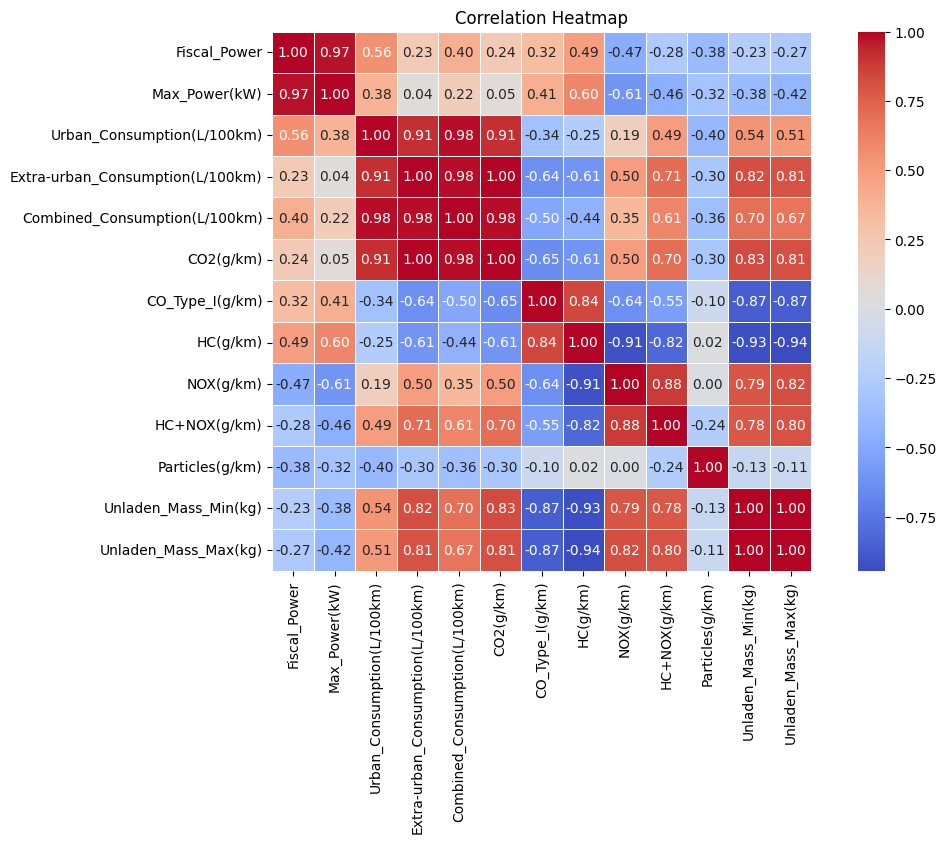

In [ ]:
#importing libraries
import matplotlib.pyplot as plt
import seaborn as sns

#calculating correlation
plt.figure(figsize=(12, 7))
df_corr_matrix = df_num.corr()

#heat map generation
sns.heatmap(df_corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

The CO2 seems to be: <br> 
- high positiv correlated with the Car Maximum Mass and <br>
"HC + NOX" 
- negatively correlated with CO Type I and HC. <br>
ATTENTION: It's a bit strange that these last two are negatively correlated with CO2. 

### Multicolinearity
There are some variables that show Multicolinearity, we could look for them with a variance inflation factor

In [ ]:
#importing libraries
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [85]:
# VIF calculation
vif = pd.DataFrame()
vif["Variable"] = df_num.columns
vif["VIF"] = [variance_inflation_factor(df_num.values, i) for i in range(df_num.shape[1])]

print(vif)

                            Variable           VIF
0                       Fiscal_Power  2.247420e+04
1                      Max_Power(kW)  1.751192e+04
2         Urban_Consumption(L/100km)  3.173689e+06
3   Extra-urban_Consumption(L/100km)  2.149112e+06
4      Combined_Consumption(L/100km)  1.079079e+07
5                          CO2(g/km)  2.347924e+04
6                    CO_Type_I(g/km)  9.487487e+01
7                           HC(g/km)  5.946665e+03
8                          NOX(g/km)  1.609529e+03
9                       HC+NOX(g/km)  6.921638e+02
10                   Particles(g/km)  5.913185e+01
11              Unladen_Mass_Min(kg)  2.521753e+04
12              Unladen_Mass_Max(kg)  2.848056e+04


With this we can conclude adjustment for the next variables
1. Urban, Extra-urban, and Combined Consumption are high correlated <br>
 with CO2
Suggestion: In the future for the analysis with the EEA Data base, <br> 
maybe would be ok if we just keep CO2 Consumption
2. Max_Power vs Fiscal_Power are almost the same
Suggestion: Keep only one (e.g., Max_Power(kW)<br>
 is more physically 
 meaningful)
3. Unladen Mass Min vs Max: Close to be redundant
Suggestion: Keep max
4. Pollutant Gases (NOX, HC, Particles, HC+NOX)
Sggestion: in the future if we concentrate in CO2 pollution, <br>
we could drop them



### Correlation of Variables

#### But first, how is CO2 Distributed?

Text(0.5, 1.0, 'CO₂ Distribution')

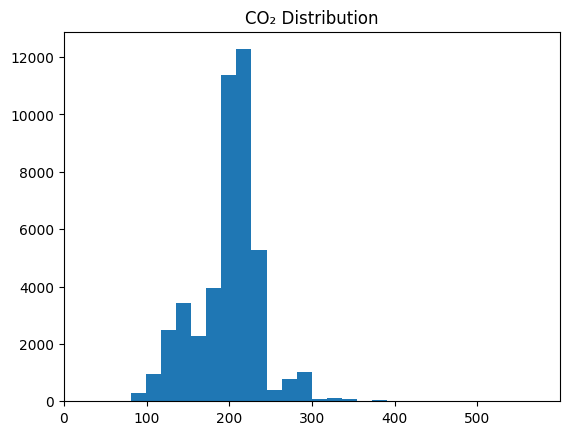

In [ ]:
#CO2 Distribution
plt.hist(df['CO2(g/km)'], bins = 30)
plt.title('CO₂ Distribution')


Text(0.5, 1.0, 'CO₂ Distribution')

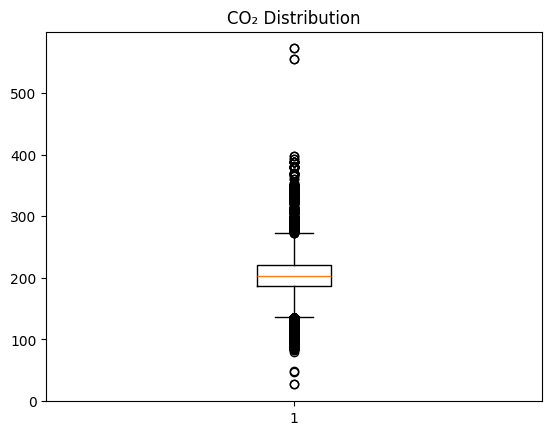

In [ ]:
#box plot of distribution
plt.boxplot(x = df['CO2(g/km)'].dropna())
plt.title('CO₂ Distribution')

Those consumptions above 400 are real and not outliers.

In [ ]:
#outliers?
df[(df['CO2(g/km)']) > 500]

,Brand,Project_Model,UTAC_Model,Commercial_Name,CNIT,TVV,Fuel_Type,Hybrid,Fiscal_Power,Max_Power(kW),...,HC(g/km),NOX(g/km),HC+NOX(g/km),Particles(g/km),Unladen_Mass_Min(kg),Unladen_Mass_Max(kg),Field_V9,Update_Date,Body_Type,Segment
115,ASTON MARTIN,ONE-77,ONE-77,ONE-77,M10SCFVP000R087,VHYA1RONE77,ES,non,80.0,559.3,...,0.075,0.056,NaN,NaN,1815.0,1815.0,715/2007*692/2008EURO5,mars-13,COUPE,LUXE
116,ASTON MARTIN,ONE-77,ONE-77,ONE-77,M10SCFVP000Y155,VHYA1RONE77,ES,non,81.0,559.3,...,0.067,0.049,NaN,NaN,1815.0,1815.0,715/2007*692/2008EURO5,mars-13,COUPE,LUXE
117,ASTON MARTIN,ONE-77,ONE-77,ONE-77,M10SCFVP000S088,VHYA2LONE77,ES,non,80.0,559.3,...,0.075,0.056,NaN,NaN,1815.0,1815.0,715/2007*692/2008EURO5,mars-13,COUPE,LUXE
118,ASTON MARTIN,ONE-77,ONE-77,ONE-77,M10SCFVP000Z156,VHYA2LONE77,ES,non,81.0,559.3,...,0.067,0.049,NaN,NaN,1815.0,1815.0,715/2007*692/2008EURO5,mars-13,COUPE,LUXE


Yes!, a car could consume that much per kilometers. Maybe it would be also <br>
interesting to investigate what does this car have that it makes it being <br>
very emmissive

In [ ]:
#lowest range
df[(df['CO2(g/km)']) < 125]

,Brand,Project_Model,UTAC_Model,Commercial_Name,CNIT,TVV,Fuel_Type,Hybrid,Fiscal_Power,Max_Power(kW),...,HC(g/km),NOX(g/km),HC+NOX(g/km),Particles(g/km),Unladen_Mass_Min(kg),Unladen_Mass_Max(kg),Field_V9,Update_Date,Body_Type,Segment
27,ALFA-ROMEO,GIULIETTA,GIULIETTA,GIULIETTA 1.4 TB MultiAir TCT (170ch) S/S,M10ALFVP000R314,940FXB1110,ES,non,9.0,125.0,...,0.037,0.030,NaN,NaN,1380.0,1380.0,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-INFER
28,ALFA-ROMEO,GIULIETTA,GIULIETTA,GIULIETTA 1.4 TB MultiAir TCT (170ch) S/S,M10ALFVP000R315,940FXB1110B,ES,non,9.0,125.0,...,0.037,0.030,NaN,NaN,1380.0,1380.0,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-INFER
29,ALFA-ROMEO,GIULIETTA,GIULIETTA,GIULIETTA 1.4 TB MultiAir TCT (170ch) S/S,M10ALFVP000S316,940FXB1110C,ES,non,9.0,125.0,...,0.037,0.030,NaN,NaN,1380.0,1380.0,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-INFER
30,ALFA-ROMEO,GIULIETTA,GIULIETTA,GIULIETTA 1.4 TB MultiAir TCT (170ch) S/S,M10ALFVP000T317,940FXB1110D,ES,non,9.0,125.0,...,0.037,0.030,NaN,NaN,1380.0,1380.0,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-INFER
40,ALFA-ROMEO,GIULIETTA,GIULIETTA,GIULIETTA 1.6 JTDm (105ch) S/S,M10ALFVP000J342,940FXD1A03,GO,non,5.0,77.0,...,NaN,0.173,0.207,0.001,1385.0,1385.0,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-INFER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44815,VOLVO,V60,V60,V60 D2 (115ch) Stop&Start Powershift 6,M10VLVVP671E600,FW84AB,GO,non,6.0,84.0,...,NaN,0.159,0.167,0.001,1556.0,1556.0,715/2007*566/2011EURO5,juin-13,BREAK,SUPERIEURE
44818,VOLVO,V60,V60,V60 D4 (163ch) Stop&Start BVM6,M10VLVVP8746741,FW88A1,GO,non,8.0,120.0,...,NaN,0.124,0.135,0.001,1590.0,1590.0,715/2007*630/2012EURO5,juin-13,BREAK,SUPERIEURE
44820,VOLVO,V60 HYBRID,V60,V60 PLUG-IN HYBRID D6 Geartronic 6 AWD,M10VLVVP872D495,GWAA50,GL,oui,10.0,158.0,...,NaN,0.036,0.038,0.000,1954.0,1954.0,715/2007*459/2012EURO5,juin-13,BREAK,SUPERIEURE
44822,VOLVO,V70,V70,V70 D3 (136ch) Stop&Start BVM6,M10VLVVP872A564,BW31A1,GO,non,7.0,100.0,...,NaN,0.159,0.170,0.001,1671.0,1671.0,715/2007*630/2012EURO5,juin-13,BREAK,SUPERIEURE


#### Does Fuel Type has a relationship with CO2 Emissions?

In order to see if the Maximal Mass has an influence in the CO2, we should <br>
differentiate those cars that use Gasoline/Diesel and the electric ones. Lets <br>
make first an exploration of how is the data of fuel type

In [ ]:
#which categories there are and their proportion
df['Fuel_Type'].value_counts(normalize=True)

Fuel_Type
GO       0.842319
ES       0.137280
EH       0.004437
GN/ES    0.003924
ES/GN    0.003924
GP/ES    0.002230
ES/GP    0.002230
GN       0.001315
GH       0.001204
EL       0.000870
FE       0.000178
EE       0.000067
GL       0.000022
Name: proportion, dtype: float64

The first 3 Categories (GO, ES and EH) are already the 97% <br>
of the cars total. <br>
85% of the cars are driven with gasoline <br>
and 13% are diesel, below the 1% is hybrid

In [ ]:
#top 3
df['Fuel_Type'].value_counts(normalize=True).keys()[0:3]



Index(['GO', 'ES', 'EH'], dtype='object', name='Fuel_Type')

On the internet we could figure out, what GO, ES and EH mean

In [92]:
labels = {"GO": "Gasoline", "ES":"Diesel", "EH": "hybrid"}

lets take only gasoline and diesel and plot their distribution

C:\Users\silva\AppData\Local\Temp\ipykernel_15188\1218593849.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig.set_xticklabels(['Gasoline','Diesel','Hybrid'])


Text(0.5, 1.0, 'CO₂ Emissions by Fuel Type')

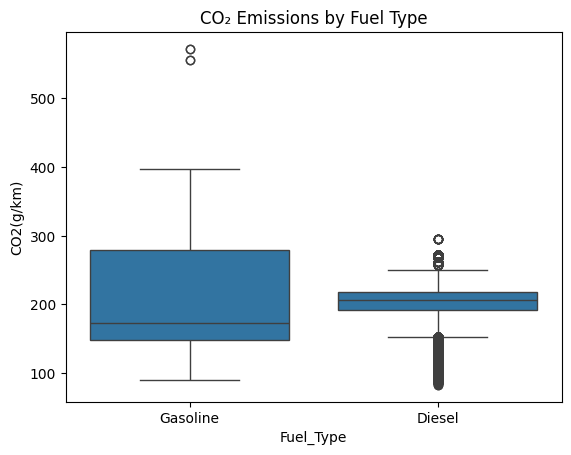

In [ ]:
#filtering gasoline and diesel
df_filter = df[(df['Fuel_Type'] == 'ES') | (df['Fuel_Type'] == 'GO')]

#ploting boxplot
fig = sns.boxplot(x=df_filter['Fuel_Type'], y=df_filter['CO2(g/km)'])

#adjusting xticks labels
fig.set_xticklabels(['Gasoline','Diesel','Hybrid'])

#adjusting title
plt.title('CO₂ Emissions by Fuel Type')


The mean between gasoline and diesel has a difference, is this <br>
a significant difference? <br>

let's apply Welch's t-test in order to respond this question:<br>
<br>
    - H0: There is no significant difference in the CO2 Consumption<br>
    levels between Gasoline and Diesel.<br>
    <br>
    - H1: There is a significant difference in the CO2 Consumption <br>
    levels between Gasoline and Diesel.<br>
        

In [ ]:
from scipy.stats import ttest_ind

# Filter CO₂ data for each fuel type
es_co2 = df_filter[df_filter['Fuel_Type'] == 'ES']['CO2(g/km)']
go_co2 = df_filter[df_filter['Fuel_Type'] == 'GO']['CO2(g/km)']

# Apply Welch's t-test (does not assume equal variances)
t_stat, p_value = ttest_ind(es_co2, go_co2, equal_var=False)

#printing values
print("T-statistic:", t_stat)
print("p-value:", p_value)
if p_value>0.05:
    print("p_value>0.05 Fail to reject the null (not significant difference)")
else:
    print("p_value<0.05 Reject the null hypothesis (significant difference)")

T-statistic: 0.3724281026518655
p-value: 0.7095860630521096
p_value>0.05 Fail to reject the null (not significant difference)


#### Does Maximal mass has a relationship with CO2 Emissions?

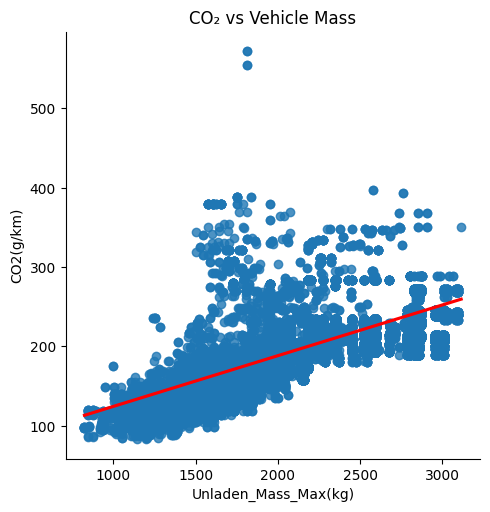

In [ ]:
#generating lmplot
sns.lmplot(x='Unladen_Mass_Max(kg)', y='CO2(g/km)',
           line_kws={'color': 'red'},
           data= df_filter)
#adjusting title
plt.title('CO₂ vs Vehicle Mass')
plt.show()

it seems to be a relationship between Mass and CO2 <br>

let's make "Pearson's r" test perform to see if there is a linear <br>
correlation

In [ ]:
# Example: mass vs CO2
from scipy.stats import pearsonr
r, p = pearsonr(df_filter['Unladen_Mass_Max(kg)'], df_filter['CO2(g/km)'])

# printing values obtained
print("Correlation coefficient (r):", r)
print("p-value:", p)


Correlation coefficient (r): 0.6724436516215777
p-value: 0.0


The r value is high so there is strong positive correlation <br>
and the p-value: < 0.05, so it is significant the relationship <br>
so: Does Maximal mass has a relationship with CO2 Emissions?<br>
YES it has a strong positive relationship

#### Does Body Type has a relationship with CO2 Consumption?

In [ ]:
#filtering main body types
main_bt = df_filter['Body_Type'].value_counts(normalize=True).index[:5]
main_bt

Index(['MINIBUS', 'BERLINE', 'BREAK', 'TS TERRAINS/CHEMINS', 'COUPE'], dtype='object', name='Body_Type')

In [98]:
#filter main body types (for visualisation)
df_filter_bt = df_filter[df_filter['Body_Type'].isin(main_bt)]

In [ ]:
#distribtion of main body types
df_filter_bt['Body_Type'].value_counts()

Body_Type
MINIBUS                32544
BERLINE                 4549
BREAK                   2254
TS TERRAINS/CHEMINS     1209
COUPE                   1097
Name: count, dtype: int64

C:\Users\silva\AppData\Local\Temp\ipykernel_15188\2922057836.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig.set_xticklabels(["Station Wagon", 'Sedan ', 'Convertible', 'Coupe', "SUV", "MPV", "Minivan_Comp.","Minibus","Ut_Van"])


[Text(0, 0, 'Station Wagon'),
 Text(1, 0, 'Sedan '),
 Text(2, 0, 'Convertible'),
 Text(3, 0, 'Coupe'),
 Text(4, 0, 'SUV'),
 Text(5, 0, 'MPV'),
 Text(6, 0, 'Minivan_Comp.'),
 Text(7, 0, 'Minibus'),
 Text(8, 0, 'Ut_Van')]

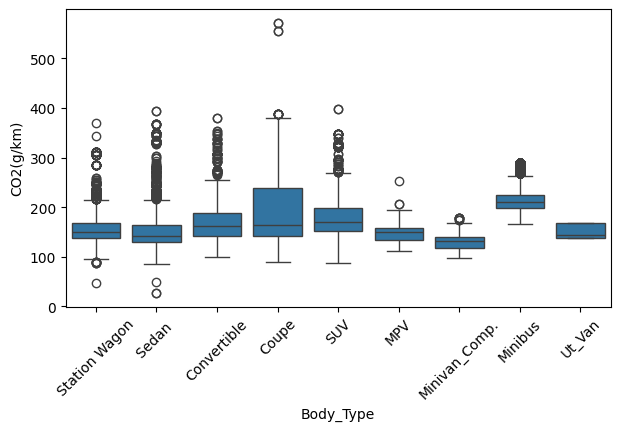

In [ ]:

#ploting
fig = sns.boxplot(x=df_filter_seg['Body_Type'], y=df_filter_seg['CO2(g/km)'])


#tighlayout
plt.tight_layout()

#adjusting labels
fig.set_xticklabels(["Station Wagon", 'Sedan ', 'Convertible', 'Coupe', "SUV", "MPV", "Minivan_Comp.","Minibus","Ut_Van"])
plt.xticks(rotation=45) # rotation


We see that even minimum co2 consumption value is above the median of all <br>
the others body types. Then maybe the body type has an influence in the <br>
co2 Emmision. That gives us already a hint, so there is something about <br>
the size of it. Is it the Minibus the heaviest type of car?

In [ ]:
from scipy.stats import f_oneway

#grouping
groups = [
    group['CO2(g/km)'].dropna()
    for name, group in df_filter.groupby('Body_Type')
]

# Perform ANOVA
f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 3832.5821432623975
p-value: 0.0


The p-value is less than 0.05, so there is a significant difference<br>

In [103]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df_filter['CO2(g/km)'], groups=df_filter['Body_Type'], alpha=0.05)
print(tukey)

             Multiple Comparison of Means - Tukey HSD, FWER=0.05              
      group1             group2       meandiff p-adj   lower    upper   reject
------------------------------------------------------------------------------
          BERLINE               BREAK  10.9492    0.0   8.6232  13.2753   True
          BERLINE           CABRIOLET  24.5952    0.0  20.6817  28.5088   True
          BERLINE          COMBISPACE   1.8308 0.7927  -1.5655   5.2272  False
          BERLINE               COUPE  47.4919    0.0  44.4544  50.5293   True
          BERLINE             MINIBUS  64.4797    0.0  63.0503  65.9091   True
          BERLINE           MINISPACE -19.9233    0.0 -27.7261 -12.1205   True
          BERLINE           MONOSPACE   0.4001    1.0  -8.1628   8.9631  False
          BERLINE   MONOSPACE COMPACT -18.6075    0.0  -22.559 -14.6561   True
          BERLINE TS TERRAINS/CHEMINS  31.6993    0.0  28.7774  34.6212   True
            BREAK           CABRIOLET   13.646    0.

we see that the Minibus Mean is significantly bigger than the the other ones <br>


C:\Users\silva\AppData\Local\Temp\ipykernel_15188\274505071.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig.set_xticklabels(["Station Wagon", 'Sedan ', 'Convertible', 'Coupe', "SUV", "MPV", "Minivan_Comp.","Minibus","Ut_Van"])


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Station Wagon'),
  Text(1, 0, 'Sedan '),
  Text(2, 0, 'Convertible'),
  Text(3, 0, 'Coupe'),
  Text(4, 0, 'SUV'),
  Text(5, 0, 'MPV'),
  Text(6, 0, 'Minivan_Comp.'),
  Text(7, 0, 'Minibus'),
  Text(8, 0, 'Ut_Van')])

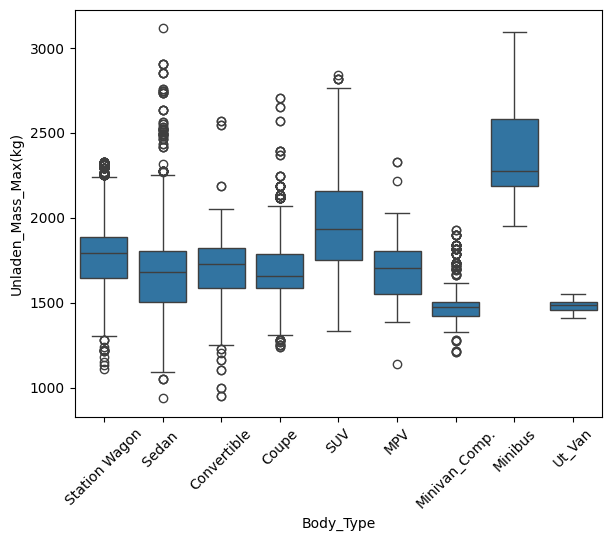

In [118]:
#plot generation
fig = sns.boxplot(x=df_filter_seg['Body_Type'], y=df_filter_seg['Unladen_Mass_Max(kg)'])



plt.tight_layout()

#adjusting xtickslabels
fig.set_xticklabels(["Station Wagon", 'Sedan ', 'Convertible', 'Coupe', "SUV", "MPV", "Minivan_Comp.","Minibus","Ut_Van"])
plt.xticks(rotation=45)


Yes, mini Bus is the heaviest, and in order to bring heavier masses <br>
you must use more combustible and therefore higher emission levels.

#### Does the gear box type has a relationship with CO2 Emmisions?

In [105]:
df_filter['Gearbox'].value_counts(normalize=True)

Gearbox
M 6    0.438671
A 5    0.308797
A 7    0.188506
M 5    0.025265
A 6    0.024878
A 8    0.009764
V 0    0.001343
D 5    0.000888
A 4    0.000865
D 7    0.000478
M 7    0.000273
D 6    0.000250
S 6    0.000023
Name: proportion, dtype: float64

In [106]:
df_filter

,Brand,Project_Model,UTAC_Model,Commercial_Name,CNIT,TVV,Fuel_Type,Hybrid,Fiscal_Power,Max_Power(kW),...,HC(g/km),NOX(g/km),HC+NOX(g/km),Particles(g/km),Unladen_Mass_Min(kg),Unladen_Mass_Max(kg),Field_V9,Update_Date,Body_Type,Segment
0,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000G340,939AXN1B52C,ES,non,12.0,147.0,...,0.052,0.032,NaN,0.002,1505.0,1505.0,715/2007*692/2008EURO5,juin-13,BREAK,MOY-SUPER
1,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch) ECO,M10ALFVP000U221,939AXP1B54C,GO,non,9.0,125.0,...,NaN,0.169,0.190,0.003,1565.0,1565.0,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
2,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000E302,939AXR1B64,GO,non,7.0,100.0,...,NaN,0.149,0.175,0.001,1565.0,1565.0,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
3,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000F303,939AXR1B64B,GO,non,7.0,100.0,...,NaN,0.149,0.175,0.001,1565.0,1565.0,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
4,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch),M10ALFVP000G304,939AXS1B66,GO,non,9.0,125.0,...,NaN,0.164,0.193,0.001,1565.0,1565.0,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44845,VOLVO,XC70,XC70,XC70 D4 (163ch) AWD Geartronic 6,M10VLVVP874P723,BZ8756,GO,non,10.0,120.0,...,NaN,0.116,0.152,0.000,1799.0,1799.0,715/2007*630/2012EURO5,juin-13,BREAK,SUPERIEURE
44846,VOLVO,XC70,XC70,XC70 D4 (163ch) Stop&Start AWD BVM6,M10VLVVP8725584,BZ87A4,GO,non,9.0,120.0,...,NaN,0.106,0.144,0.000,1786.0,1786.0,715/2007*630/2012EURO5,juin-13,BREAK,SUPERIEURE
44847,VOLVO,XC70,XC70,XC70 D4 (163ch) Geartronic 6,M10VLVVP8726585,BZ8850,GO,non,9.0,120.0,...,NaN,0.108,0.132,0.001,1726.0,1726.0,715/2007*630/2012EURO5,juin-13,BREAK,SUPERIEURE
44848,VOLVO,XC70,XC70,XC70 D4 (163ch) Stop&Start BVM6,M10VLVVP8727586,BZ88A1,GO,non,9.0,120.0,...,NaN,0.127,0.152,0.001,1706.0,1706.0,715/2007*630/2012EURO5,juin-13,BREAK,SUPERIEURE


In [107]:
main_gb = ['M 6','A 5','A 7'] #90% of the data falls into these three categories

df_filter_mgb = df_filter[df_filter['Gearbox'].isin(main_gb)]


In [108]:
df_filter_mgb['Gearbox'].value_counts(normalize=True)

Gearbox
M 6    0.468679
A 5    0.329921
A 7    0.201401
Name: proportion, dtype: float64

C:\Users\silva\AppData\Local\Temp\ipykernel_15188\298571972.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig.set_xticklabels(['Manual 6 ','Autom. 5','Autom. 7'])


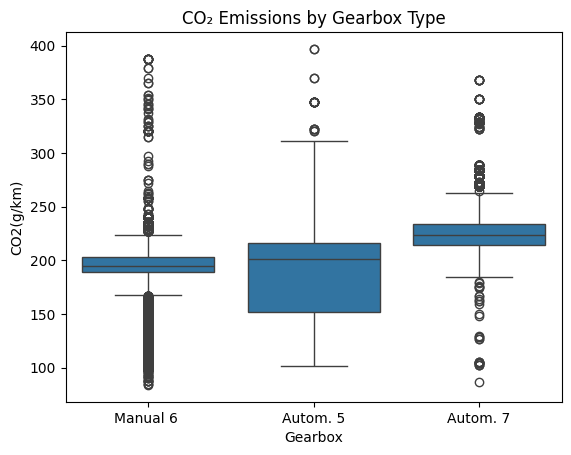

In [109]:

fig = sns.boxplot(x=df_filter_mgb['Gearbox'], y=df_filter_mgb['CO2(g/km)'])

fig.set_xticklabels(['Manual 6 ','Autom. 5','Autom. 7'])
plt.title('CO₂ Emissions by Gearbox Type')

plt.show()


Between Manual and automatic 5 (5 gears) there is a slightly <br>
difference in the mean. The automatic 7 has a higher mean than the<br>
other two. But is it this difference due to the gearbox type <br>
or because this 'gearbox' type are mainly to see in "sport" cars <br>
or  in cars bigger than standard cars? <br>. In those cases the <br> 
cylinders are bigger and therefore more CO2 consumption?


In [110]:
df_filter_mgb[df_filter_mgb['Gearbox'] == 'A 7']['Body_Type'].value_counts(normalize=True)

Body_Type
MINIBUS                0.412340
BERLINE                0.243057
BREAK                  0.143927
COUPE                  0.064598
TS TERRAINS/CHEMINS    0.062545
CABRIOLET              0.033084
MONOSPACE COMPACT      0.028013
COMBISPACE             0.012437
Name: proportion, dtype: float64

We don't see really a pattern

#### Does the segment has a relationship with CO2 Consumption?

In [111]:
df_filter['Segment'].value_counts(normalize=True)

Segment
MOY-INFER     0.458382
MOY-SUPER     0.344008
LUXE          0.114100
SUPERIEURE    0.044338
INFERIEURE    0.034915
ECONOMIQUE    0.004211
MOY-INF       0.000046
Name: proportion, dtype: float64

In [112]:
main_seg = df_filter["Segment"].value_counts().index[:4]

main_seg

Index(['MOY-INFER', 'MOY-SUPER', 'LUXE', 'SUPERIEURE'], dtype='object', name='Segment')

In [113]:
df_filter_seg = df[df["Segment"].isin(main_seg)]

C:\Users\silva\AppData\Local\Temp\ipykernel_15188\627092353.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig.set_xticklabels(['Lower-Mid Segment', 'Upper-Mid Segment ', 'Luxury', 'Upper Segment'])


[Text(0, 0, 'Lower-Mid Segment'),
 Text(1, 0, 'Upper-Mid Segment '),
 Text(2, 0, 'Luxury'),
 Text(3, 0, 'Upper Segment')]

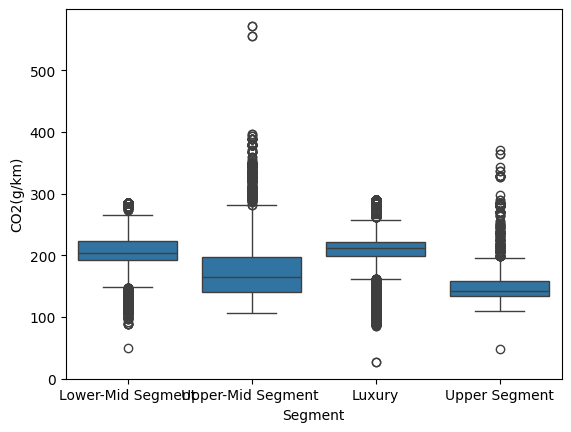

In [114]:

fig = sns.boxplot(x=df_filter_seg['Segment'], y=df_filter_seg['CO2(g/km)'])

fig.set_xticklabels(['Lower-Mid Segment', 'Upper-Mid Segment ', 'Luxury', 'Upper Segment'])



#### Does Max Power has a relationship with CO2 Consumption?

In [ ]:
#distribution of bodytype
df_filter['Body_Type'].value_counts(normalize=True)

Body_Type
MINIBUS                0.740731
BERLINE                0.103539
BREAK                  0.051303
TS TERRAINS/CHEMINS    0.027518
COUPE                  0.024969
COMBISPACE             0.019051
CABRIOLET              0.013725
MONOSPACE COMPACT      0.013429
MINISPACE              0.003141
MONOSPACE              0.002595
Name: proportion, dtype: float64

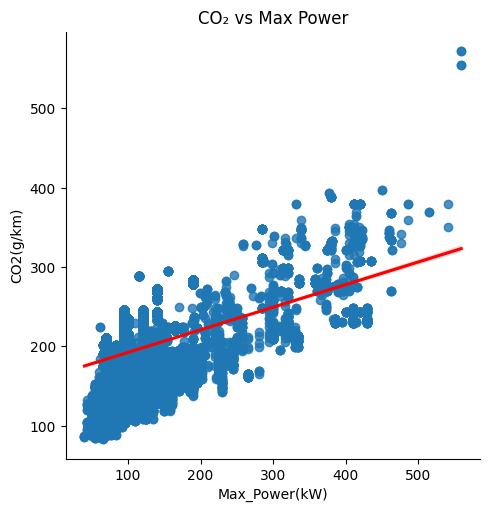

In [ ]:
#lmplot plotting
sns.lmplot(x='Max_Power(kW)', y='CO2(g/km)',
            line_kws={'color': 'red'},
           data= df_filter)

#adjusting title
plt.title('CO₂ vs Max Power')
plt.show()

The Max Power seems to be strongly related with CO2 emmsion, this <br>
makes sense because 
is also other hypothesis we have to explore

In [117]:
# Mass vs CO2
r, p = pearsonr(df_filter['Max_Power(kW)'], df_filter['CO2(g/km)'])

print("Correlation coefficient (r):", r)
print("p-value:", p)

Correlation coefficient (r): 0.3646880782020383
p-value: 0.0


it has a moderate relationship, not strong as <br>
mass though.<br>
This makes sense mechanically too — heavier cars naturally <br>
require more fuel, regardless of how powerful the engine is.

### The variables that has a significant difference are: <br> max power and car mass Car mass has <br> a higher influence than the max  power this variables <br> werden analysed in the next data base